<a href="https://colab.research.google.com/github/SuryaThejas-07/NeuroGraph_Explorer/blob/main/GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Install the required libraries
!pip install torch_geometric
!pip install optuna

In [2]:
import torch
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch.nn import Linear
from torch_geometric.nn import GCNConv
import pandas as pd


In [3]:
#Load the Karate Club dataset
dataset = KarateClub()
data = dataset[0]

In [4]:
print(dataset.num_features)

34


In [5]:
#Convert the node features to a pandas dataframe
node_features_df = pd.DataFrame(data.x.numpy(), columns=[f'feature_{i}' for i in range(data.x.shape[1])])
node_features_df['node'] = node_features_df.index
node_features_df.set_index('node', inplace=True)

In [6]:
#Convert the edge index to a pandas dataframe
edge_index_df = pd.DataFrame(data.edge_index.numpy().T, columns=['source', 'target'])

In [7]:
#Convert labels to a pandas dataframe
labels_df = pd.DataFrame(data.y.numpy(), columns=['label'])
labels_df['node'] = labels_df.index
labels_df.set_index('node', inplace=True)

In [8]:
print(node_features_df)

#As we say they contain the adjaency in the result

      feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
node                                                                     
0           1.0        0.0        0.0        0.0        0.0        0.0   
1           0.0        1.0        0.0        0.0        0.0        0.0   
2           0.0        0.0        1.0        0.0        0.0        0.0   
3           0.0        0.0        0.0        1.0        0.0        0.0   
4           0.0        0.0        0.0        0.0        1.0        0.0   
5           0.0        0.0        0.0        0.0        0.0        1.0   
6           0.0        0.0        0.0        0.0        0.0        0.0   
7           0.0        0.0        0.0        0.0        0.0        0.0   
8           0.0        0.0        0.0        0.0        0.0        0.0   
9           0.0        0.0        0.0        0.0        0.0        0.0   
10          0.0        0.0        0.0        0.0        0.0        0.0   
11          0.0        0.0        0.0 

In [9]:
#Print the number of nodes
num_nodes = data.num_nodes
print(f'Number of nodes: {num_nodes}')

Number of nodes: 34


In [10]:
#Print the number of edges
num_edges = data.edge_index.shape[1]
print(f'Number of edges: {num_edges}')


Number of edges: 156


In [11]:
#Print th node feature Dataframe
print(f"\nNode features (shape: {node_features_df.shape}):  ")
print(node_features_df.head()) #prints only the first row for brevity



Node features (shape: (34, 34)):  
      feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
node                                                                     
0           1.0        0.0        0.0        0.0        0.0        0.0   
1           0.0        1.0        0.0        0.0        0.0        0.0   
2           0.0        0.0        1.0        0.0        0.0        0.0   
3           0.0        0.0        0.0        1.0        0.0        0.0   
4           0.0        0.0        0.0        0.0        1.0        0.0   

      feature_6  feature_7  feature_8  feature_9  ...  feature_24  feature_25  \
node                                              ...                           
0           0.0        0.0        0.0        0.0  ...         0.0         0.0   
1           0.0        0.0        0.0        0.0  ...         0.0         0.0   
2           0.0        0.0        0.0        0.0  ...         0.0         0.0   
3           0.0        0.0        0.0   

In [12]:
#Print edge indices Dataframe
print(f"\nEdge indices (shape: {edge_index_df.shape}):  ")
print(edge_index_df.head()) #Print only the first rows for brevity


Edge indices (shape: (156, 2)):  
   source  target
0       0       1
1       0       2
2       0       3
3       0       4
4       0       5


In [13]:
#Print labels dataframe
print(f"\nLabels (shape: {labels_df.shape}):  ")
print(labels_df.head()) #Print only the first rows for brevity


Labels (shape: (34, 1)):  
      label
node       
0         1
1         1
2         1
3         1
4         3


In [14]:
#Number of countries
num_countries=4

#Assign students to countries (labels)
np.random.seed(42)
countries = torch.tensor(np.random.choice(num_countries,data.num_nodes))

In [15]:
#Update the labels in the data object
data.y=countries

In [16]:
# Verify the data
print(data)
print(f'x={data.x.shape}')
print(data.x)
print(f'edge_index={data.edge_index.shape}')
print(data.edge_index)
print(f'y={data.y.shape}')
print(data.y)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
x=torch.Size([34, 34])
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
edge_index=torch.Size([2, 156])
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 

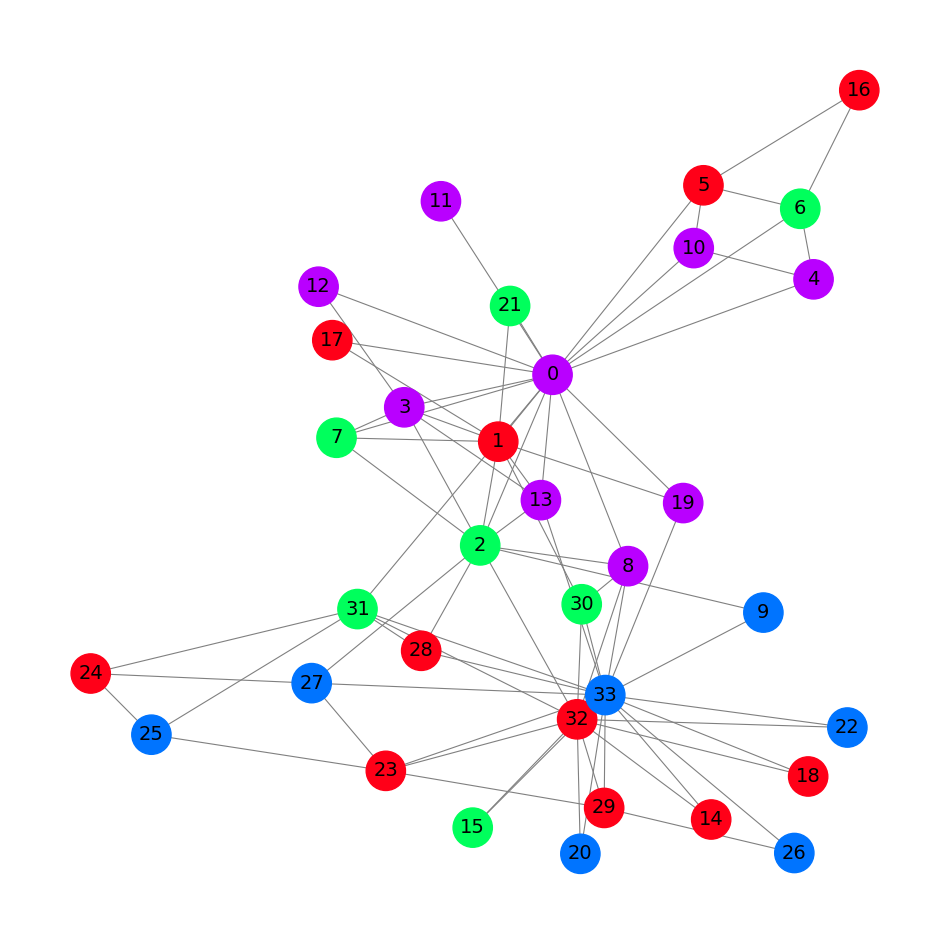

In [17]:
#Check if the graph is as expected
G=to_networkx(data, to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G,
                 pos=nx.spring_layout(G, seed=0),
                 with_labels=True,
                 node_size=800,
                 node_color=data.y,
                 cmap="hsv",
                 vmin=-2,
                 vmax=3,
                 width=0.8,
                 edge_color="grey",
                 font_size=14)
plt.show()

In [18]:
#Define the model
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn = GCNConv(dataset.num_features, 3)
        self.out = Linear(3, num_countries)

    def forward(self, x, edge_index):
        h=self.gcn(x,edge_index).relu()
        z=self.out(h)
        return h,z

model=GCN()
print(model)

GCN(
  (gcn): GCNConv(34, 3)
  (out): Linear(in_features=3, out_features=4, bias=True)
)


In [19]:
criterion=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=0.01)

#Calculate Accuracy

def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

In [20]:
#Data for animations
embeddings=[]
losses=[]
accuracies=[]
outputs=[]

#Training loop
for epoch in range(200):
  optimizer.zero_grad()
  h, z = model(data.x, data.edge_index)
  loss=criterion(z, data.y)
  acc=accuracy(z.argmax(dim=1), data.y)
  loss.backward()
  optimizer.step()
  embeddings.append(h)
  losses.append(loss)
  accuracies.append(acc)
  outputs.append(z.argmax(dim=1))
  if epoch % 10 == 0:
    print(f'Epoch: {epoch>3}, Loss: {loss:.4f}, Acc: {acc*100:.4f}%')



Epoch: False, Loss: 1.3772, Acc: 32.3529%
Epoch: True, Loss: 1.3271, Acc: 32.3529%
Epoch: True, Loss: 1.2675, Acc: 50.0000%
Epoch: True, Loss: 1.1976, Acc: 52.9412%
Epoch: True, Loss: 1.1252, Acc: 52.9412%
Epoch: True, Loss: 1.0554, Acc: 52.9412%
Epoch: True, Loss: 0.9897, Acc: 52.9412%
Epoch: True, Loss: 0.9262, Acc: 55.8824%
Epoch: True, Loss: 0.8632, Acc: 58.8235%
Epoch: True, Loss: 0.8005, Acc: 70.5882%
Epoch: True, Loss: 0.7395, Acc: 76.4706%
Epoch: True, Loss: 0.6814, Acc: 76.4706%
Epoch: True, Loss: 0.6284, Acc: 79.4118%
Epoch: True, Loss: 0.5815, Acc: 79.4118%
Epoch: True, Loss: 0.5414, Acc: 79.4118%
Epoch: True, Loss: 0.5066, Acc: 79.4118%
Epoch: True, Loss: 0.4757, Acc: 79.4118%
Epoch: True, Loss: 0.4468, Acc: 79.4118%
Epoch: True, Loss: 0.4190, Acc: 79.4118%
Epoch: True, Loss: 0.3941, Acc: 79.4118%


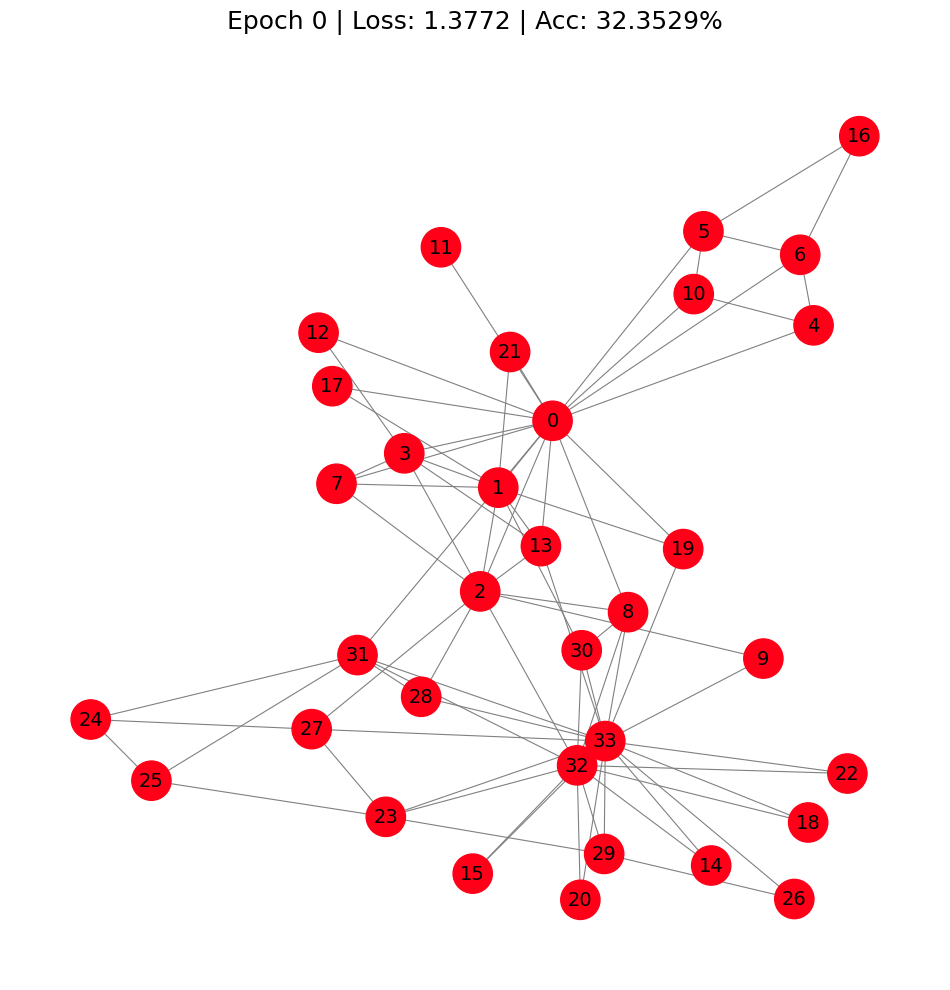

In [21]:
from IPython.display import HTML
from matplotlib import animation
import matplotlib.pyplot as plt

plt.rcParams["animation.bitrate"] = 3000

fig, ax = plt.subplots(figsize=(12,12)) # Create figure and axis once

def animate(i):
  ax.clear() # Clear the previous frame
  ax.axis('off') # Turn off axis for each frame
  G=to_networkx(data, to_undirected=True)
  nx.draw_networkx(G,
                   pos=nx.spring_layout(G, seed=0),
                   with_labels=True,
                   node_size=800,
                   node_color=outputs[i].numpy(),
                   cmap="hsv",
                   vmin=-2,
                   vmax=3,
                   width=0.8,
                   edge_color="grey",
                   font_size=14,
                   ax=ax) # Draw on the specific axis
  ax.set_title(f'Epoch {i} | Loss: {losses[i].item():.4f} | Acc: {accuracies[i]*100:.4f}%',fontsize=18,pad=20)


anim=animation.FuncAnimation(fig, animate, np.arange(0,200,10), interval=500, repeat=True)
html=HTML(anim.to_html5_video())
display(html)

Final embeddings = (h.shape)
tensor([[1.8488, 0.4847, 0.5476],
        [0.7882, 0.0754, 0.0037],
        [0.0000, 0.8323, 1.0426],
        [1.3123, 0.8991, 0.8727],
        [1.5083, 0.5923, 0.8335],
        [0.3975, 0.0154, 0.1042],
        [0.1472, 0.6392, 0.7159],
        [0.3623, 0.8471, 0.8590],
        [0.9288, 0.7389, 0.6263],
        [0.0000, 0.0000, 0.0000],
        [1.4942, 0.7105, 0.8368],
        [1.7144, 0.9874, 0.8297],
        [1.7016, 0.9910, 0.9051],
        [1.2012, 0.7271, 0.4688],
        [0.4860, 0.0000, 0.0000],
        [0.0294, 1.0442, 1.0655],
        [0.0000, 0.0000, 0.0629],
        [0.4342, 0.1268, 0.0542],
        [0.6024, 0.0000, 0.0000],
        [1.1956, 0.6646, 0.4062],
        [0.0000, 0.0000, 0.0000],
        [0.0214, 0.8193, 0.8442],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0237, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.4423, 0.

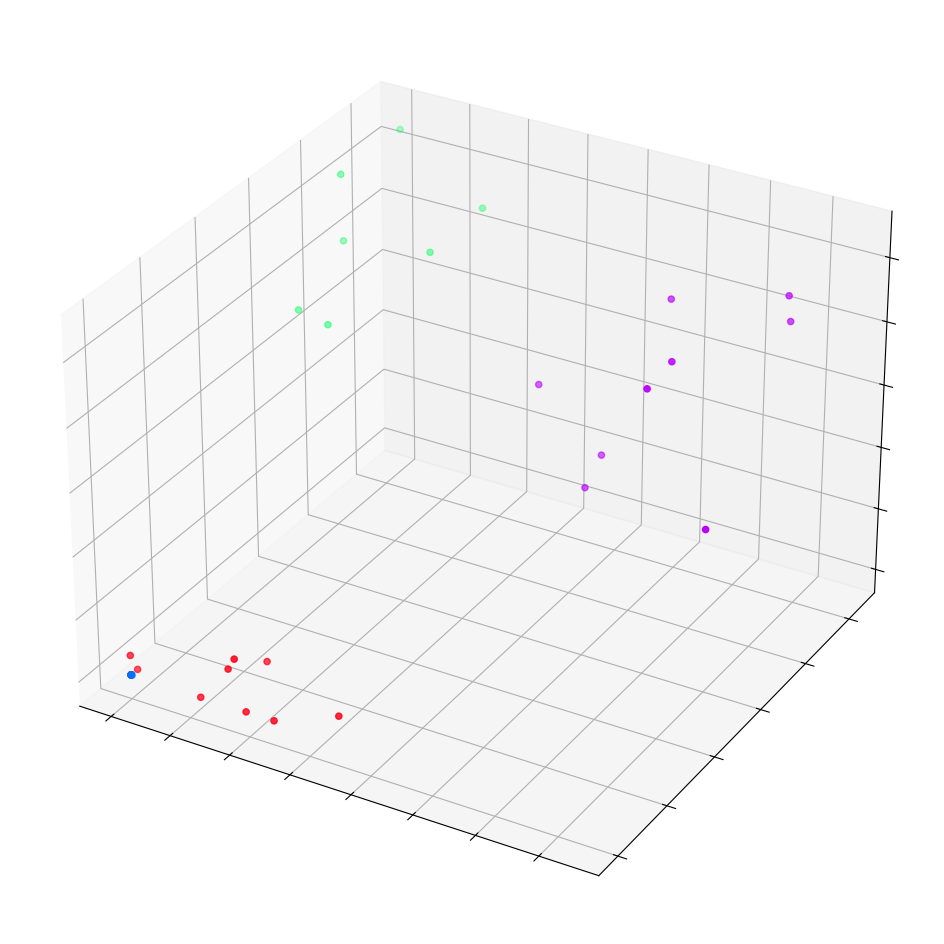

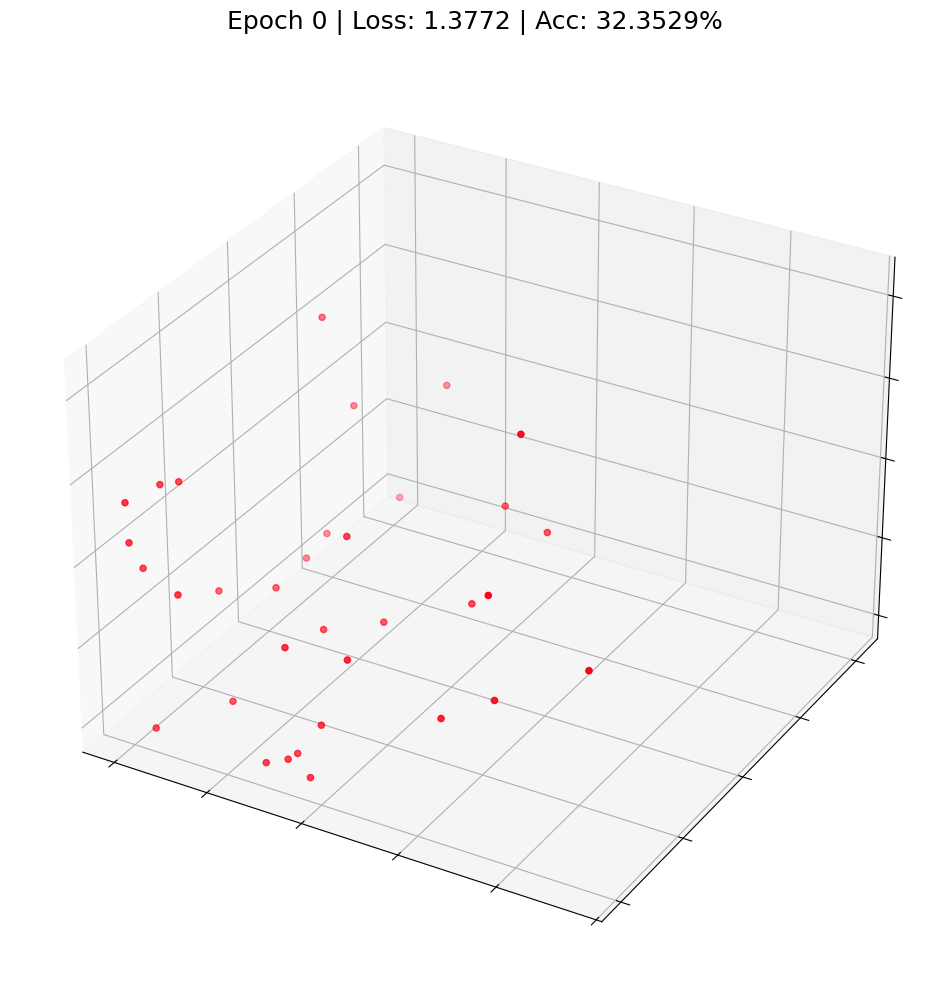

In [22]:

# 3D Embeddings Visualization
print(f'Final embeddings = (h.shape)')
print(h)
embed=h.detach().cpu().numpy()
fig = plt.figure(figsize=(12, 12))
ax=fig.add_subplot(projection='3d')
ax.patch.set_alpha(0)
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.scatter(embed[:, 0], embed[:, 1], embed[:, 2], c=data.y.numpy(), cmap="hsv", vmin=-2, vmax=3)
plt.show()


def animate_3d(i):
  embed=embeddings[i].detach().cpu().numpy()
  ax.clear()
  ax.scatter(embed[:, 0], embed[:, 1], embed[:, 2], c=outputs[i].numpy(), cmap="hsv",vmin=-2, vmax=3)
  plt.title(f'Epoch {i} | Loss: {losses[i].item():.4f} | Acc: {accuracies[i]*100:.4f}%',fontsize=18,pad=20)


fig=plt.figure(figsize=(12,12))
plt.axis('off')
ax=fig.add_subplot(projection='3d')
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
anim=animation.FuncAnimation(fig, animate_3d, np.arange(0,200,10),interval=800, repeat=True)
html=HTML(anim.to_html5_video())
display(html)


